# 7 - accDM daughter: effective sound-speed calibration (fit vs bounded vs exact)

The daughter effective sound speed `ceff2 = delta_p/delta_rho` is set by the published Eq-(38) fit:

`ceff2 = ca2 * (1 + ncdm_ceff2_fs_amp * (1 - 2*eps_acc) * sqrt(k/k_fs))`

The weight `W = 1 - 2*eps_acc` is **always in (0, 1]** for physical `eta >= 0`: `eps_acc(eta)` rises monotonically from 0 and **saturates at 1/2** (confirmed by the setup-cell sanity print: 0.29 at eta=0.1, 0.50 at eta=10), so `W -> 0` as `eta -> inf`. The fit grows like `sqrt(k/k_fs)` **without bound**, so it overshoots the causal ceiling `1/3` when the **base sound speed `ca2` is large** - a relativistic daughter at early times - times a large `k/k_fs`. It does **not** overshoot at large `eta` (there `W -> 0`). Mode 1 (`ncdm_ceff2_mode = 1`) keeps the same small-`k/k_fs` slope but caps the result at `1/3`.

**This notebook:**
1. **Diagnostic** - exact `c_s^2(k)` at `z = 0` (the paper's Fig-16 message): beyond `k_fs` the exact sound speed *oscillates and goes negative*, so the fit is a smooth **envelope**, not a pointwise match. At the production boost `eta = 0.1` the daughter is cold, the fit stays far below `1/3`, and **mode 0 == mode 1** (the bound is inactive here - this is correct, not a coincidence).
2. **What the bound does** - a deterministic plot (no CLASS run) of `ceff2` vs `k/k_fs` for several base `ca2`, showing mode 0 shoot past `1/3` for relativistic `ca2` while mode 1 saturates.
3. **Calibration on P(k)** - the meaningful metric. Pointwise `c_s^2` at `z = 0` oscillates and goes negative, so it is a poor target; instead pick `ncdm_ceff2_fs_amp` by the residual of the *observable* `P(k)` vs the exact hierarchy.
4. **Cold-limit + bounds asserts** - mode 1 reduces to the fit when cold, and `0 <= ceff2 <= 1/3` always.

Style/conventions follow `6_test_fluid_vs_exact.ipynb`. The high-k architectural blow-up (`memory: fluid-approx-unusable`) is out of scope; the exact hierarchy remains the production path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# --- base cosmology + accDM model (same setup as notebook 6) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

A_T, MASS, F_ACC, KAPPA = 0.13, 1e16, 0.1, 6.0
A_REC = 1.0 / (1.0 + 1090.0)
ETA0 = 0.1                # production energy boost

# --- speed knobs: the slow parts are opt-in (each CLASS solve is ~1-2 min) ---
RUN_DIAGNOSTIC = True    # Step 1: cs2(k) Fig-16 diagnostic (2 CLASS runs); illustrative only
CHECK_BOUND    = False    # Step 3: also run mode 1 across the sweep to measure bound activation.
                          #   With min(fit,1/3) mode 1 == mode 0 below 1/3, so this is only
                          #   informative once amp is large enough that the fit overshoots.

def accdm_params(eta, mode='exact', amp=0.2, ceff2_mode=0, trigger=None, kappa=KAPPA):
    """accDM params for a given energy boost eta. mode='exact' -> full hierarchy;
    mode='fluid' -> CLASS fluid with ncdm_ceff2_mode / ncdm_ceff2_fs_amp set."""
    ocdm = omega_cdm0 * (1 + F_ACC*(1 - A_REC**kappa)/(1 + (A_REC/A_T)**kappa))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': A_T,
              'f_acc': F_ACC, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, 1001', 'N_ur': 0.00441,
              'background_Nloga': 5001, "gauge": "synchronous", "get_perturbations_in_current_gauge": "yes",
              "ncdm_fluid_trigger_tau_over_tau_k": 25})
    if mode == 'exact':
        p['ncdm_fluid_approximation'] = 3                  # none
    else:
        p['ncdm_fluid_approximation'] = 2                  # CLASS fluid
        p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger if trigger is not None else 0.3
        p['ncdm_ceff2_mode'] = ceff2_mode
        p['ncdm_ceff2_fs_amp'] = amp
    return p

def run_pk(params, k_list):
    """Run CLASS and return P(k) at z=0 over k_list [1/Mpc]."""
    M = Class(); M.set(params); M.compute()
    pk = np.array([M.pk(float(k), 0.0) for k in k_list])
    M.struct_cleanup(); M.empty()
    return pk

# --- Python port of the C helper perturbations_ceff2_ncdm (keep in sync) ---
# mode 0 = Eq-38 fit; mode 1 = same fit hard-capped at 1/3 (min(fit, 1/3)).
def ceff2_py(cs2_base, k, a, H, eps_acc, amp=0.2, mode=0):
    cs2 = np.asarray(cs2_base, float)
    pos = cs2 > 0
    W   = 1.0 - 2.0*eps_acc
    xr  = np.sqrt(k*np.sqrt(2./3.)*np.sqrt(np.where(pos, cs2, 1.0))/(a*H))
    fit = cs2*(1.0 + amp*W*xr)
    out = fit if mode == 0 else np.minimum(fit, 1./3.)
    return np.where(pos, out, 0.0)

# eps_acc(eta) exactly as input.c precomputes it. Monotone in [0, 1/2): -> 1/2 as eta->inf.
def eps_acc_of_eta(eta):
    e2 = eta*eta
    return -e2 + np.sqrt(e2*e2 + 4*e2*eta + 5*e2 + 2*eta) - 2*eta

print('setup OK; eps_acc(eta) sanity:', {e: round(float(eps_acc_of_eta(e)), 4) for e in [0.0, 0.1, 1.0, 10.0]})

setup OK; eps_acc(eta) sanity: {0.0: 0.0, 0.1: 0.2941, 1.0: 0.4641, 10.0: 0.499}


## Step 1 (optional diagnostic) - exact `c_s^2(k)` at `z = 0` is oscillatory; the fit is an envelope

**Gated by `RUN_DIAGNOSTIC` (default off).** This is the paper's Fig-16 message, not a calibration, and costs 2 CLASS runs. At `z = 0` the free-streaming scale `k_fs ~ 5e-3/Mpc` sits left of the whole plotted range, so every k is in the oscillatory `k > k_fs` regime where the exact `c_s^2` oscillates and even goes **negative**. The smooth fit is an envelope through that oscillation - pointwise agreement is not expected, which is why calibration uses `P(k)` (Step 3). At `eta = 0.1` the daughter is cold and the fit stays `<< 1/3`, so bounded `== fit` here (nothing to plot separately).

perturbation keys: ['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'eta_prime', 'h_prime', 'phi_prime', 'rho_plus_p_theta', 'delta_rho_tot', 'eta', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_ncdm[0]', 'theta_ncdm[0]', 'shear_ncdm[0]', 'cs2_ncdm[0]', 'w_p[0]', 'w_theta[0]', 'w_sigma[0]', 'k_fss_acc[0]', 'delta_ncdm[1]', 'theta_ncdm[1]', 'shear_ncdm[1]', 'cs2_ncdm[1]', 'w_p[1]', 'w_theta[1]', 'w_sigma[1]', 'k_fss_acc[1]', 'w_trial_1', 'w_trial_2', 'delta_dcdm', 'theta_dcdm']
eta=0.1: exact cs2 range [-8.36e-03, 7.10e-03]; k_fs~0.00566/Mpc
exact cs2(k): [ 0.00218  0.00281  0.00241  0.00221  0.0071  -0.00233  0.0004   0.00213
  0.00197  0.00222  0.00107  0.00225  0.00218  0.00125  0.00202 -0.00836
  0.00352  0.00203  0.00251  0.00026  0.00297  0.00209  0.00225  0.00126]


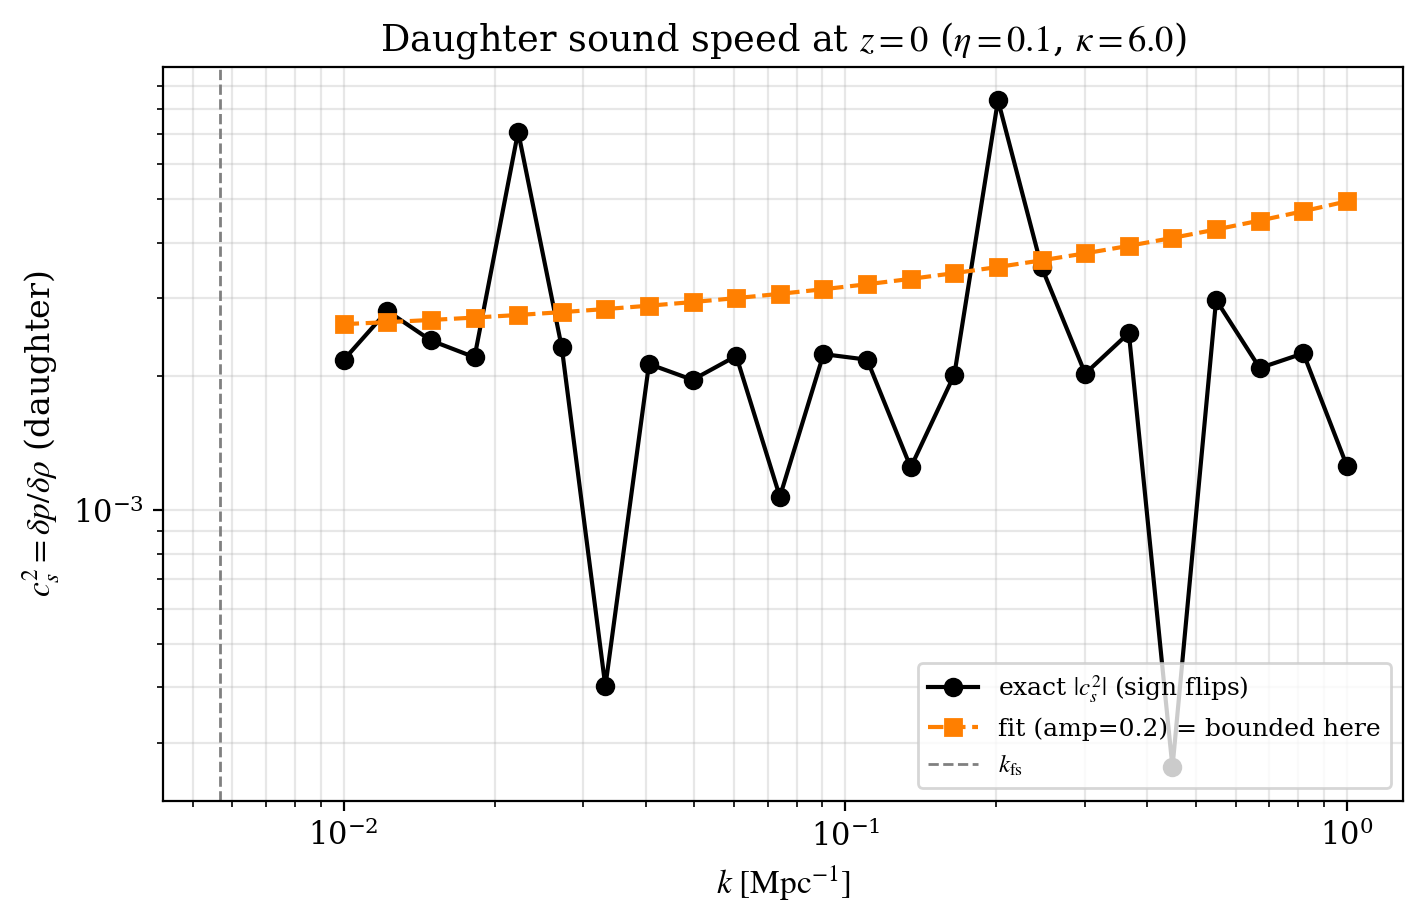

In [2]:
K_NODES = np.logspace(-2, 0.0, 24)   # 1/Mpc, spanning below to above k_fs
_keys_printed = {'done': False}

def _find_key(d, want):
    if want in d:
        return want
    for kk in d:
        if kk.replace(' ', '').startswith(want.replace(' ', '')):
            return kk
    raise KeyError('{!r} not found; available: {}'.format(want, list(d.keys())))

def run_cs2_of_k(params, k_list):
    """Run CLASS and return (cs2(k), k_fs(k)) for the daughter at z=0 (latest tau)."""
    ks = np.sort(np.asarray(k_list, float))
    p = dict(params)
    p['k_output_values'] = ', '.join('{:.8e}'.format(k) for k in ks)
    M = Class(); M.set(p)
    M.compute()
    perts = M.get_perturbations()['scalar']     # one dict per k, in sorted-k order
    if not _keys_printed['done']:
        print('perturbation keys:', list(perts[0].keys()))
        _keys_printed['done'] = True
    kcs2 = _find_key(perts[0], 'cs2_ncdm[1]')
    kkfs = _find_key(perts[0], 'k_fss_acc[1]')
    cs2 = np.array([float(d[kcs2][-1]) for d in perts])
    kfs = np.array([float(d[kkfs][-1]) for d in perts])
    M.struct_cleanup(); M.empty()
    return ks, cs2, kfs

cs2_exact = None
if not RUN_DIAGNOSTIC:
    print('Step 1 diagnostic skipped (set RUN_DIAGNOSTIC=True for the cs2(k) Fig-16 plot).')
else:
    k_ex, cs2_exact, kfs_ex = run_cs2_of_k(accdm_params(ETA0, 'exact'), K_NODES)
    k_f0, cs2_fit,   _      = run_cs2_of_k(accdm_params(ETA0, 'fluid', amp=0.2, ceff2_mode=0), K_NODES)
    kfs0 = float(np.median(kfs_ex[kfs_ex > 0])) if np.any(kfs_ex > 0) else np.nan
    print('eta={}: exact cs2 range [{:.2e}, {:.2e}]; k_fs~{:.3g}/Mpc'.format(
        ETA0, np.nanmin(cs2_exact), np.nanmax(cs2_exact), kfs0))
    print('exact cs2(k):', np.round(cs2_exact, 5))   # note the negative entries (oscillation)

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.loglog(k_ex, np.abs(cs2_exact), 'o-', color='black', label=r'exact $|c_s^2|$ (sign flips)')
    ax.loglog(k_f0, cs2_fit, 's--', color=qual_colors[1], label='fit (amp=0.2) = bounded here')
    # ax.axhline(1./3., color='red', ls=':', lw=1.2, label=r'causal ceiling $1/3$')
    if np.isfinite(kfs0):
        ax.axvline(kfs0, color='gray', ls='--', lw=1.0, label=r'$k_{\mathrm{fs}}$')
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$c_s^2 = \delta p/\delta\rho$ (daughter)')
    ax.set_title(r'Daughter sound speed at $z=0$ ($\eta={}$, $\kappa={}$)'.format(ETA0, KAPPA))
    ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)
    plt.show()

## Step 2

The bound only matters when the **base sound speed `ca2` is large** (a relativistic daughter at early times). This cell evaluates the helper port `ceff2_py` directly vs `k/k_fs` for several fixed `ca2`. With `mode 1 = min(fit, 1/3)`, the **bounded (solid) curve lies exactly on the fit (dashed) until it hits `1/3`, then stays flat** - a pure cap. For cold `ca2` the fit never reaches `1/3`, so mode 1 == mode 0 (matching Step 1); for relativistic `ca2` the fit shoots past `1/3` while mode 1 holds the ceiling. This is the entire effect of `ncdm_ceff2_mode = 1`.

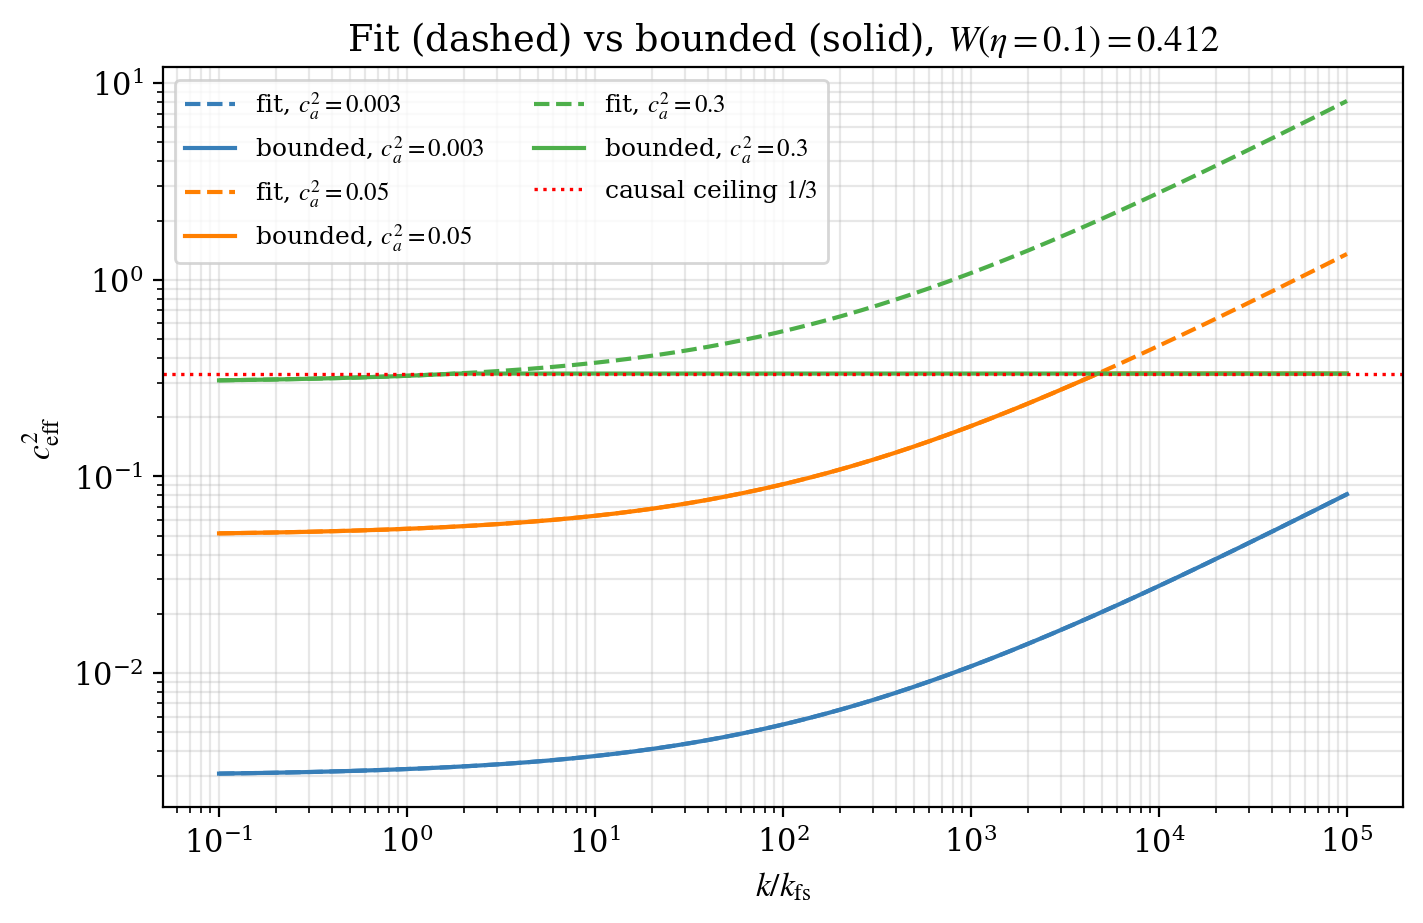

relativistic ca2=0.30: fit max = 8.114 (>1/3: True), bounded max = 0.333 (<=1/3: True)


In [3]:
# Evaluate the helper port vs x = k/k_fs at fixed base ca2. Set a=H=1 and choose
# k so that xr^2 = k*sqrt(2/3)*sqrt(ca2)/(a*H) = x, i.e. k = x / (sqrt(2/3)*sqrt(ca2)).
x = np.logspace(-1, 5, 400)                 # k/k_fs
eps0 = eps_acc_of_eta(ETA0)                  # weight at the production boost
CA2_CASES = [3e-3, 5e-2, 0.30]               # cold -> mildly rel -> relativistic

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for ca2, c in zip(CA2_CASES, qual_colors):
    base = np.full_like(x, ca2)
    kk = x / (np.sqrt(2./3.)*np.sqrt(ca2))   # a = H = 1
    c0 = ceff2_py(base, kk, 1.0, 1.0, eps0, amp=0.2, mode=0)
    c1 = ceff2_py(base, kk, 1.0, 1.0, eps0, amp=0.2, mode=1)
    ax.loglog(x, c0, '--', color=c, label=r'fit, $c_a^2={:g}$'.format(ca2))
    ax.loglog(x, c1, '-',  color=c, label=r'bounded, $c_a^2={:g}$'.format(ca2))
ax.axhline(1./3., color='red', ls=':', lw=1.2, label=r'causal ceiling $1/3$')
ax.set_xlabel(r'$k/k_{\mathrm{fs}}$')
ax.set_ylabel(r'$c_{\mathrm{eff}}^2$')
ax.set_title(r'Fit (dashed) vs bounded (solid), $W(\eta=0.1)={:.3f}$'.format(1 - 2*eps0))
ax.legend(loc='best', ncol=2); ax.grid(True, which='both', alpha=0.3)
plt.show()

# numeric confirmation: fit overshoots, bounded never does, for the relativistic case
base = np.full_like(x, 0.30); kk = x/(np.sqrt(2./3.)*np.sqrt(0.30))
fit_max = float(np.nanmax(ceff2_py(base, kk, 1.0, 1.0, eps0, amp=0.2, mode=0)))
bnd_max = float(np.nanmax(ceff2_py(base, kk, 1.0, 1.0, eps0, amp=0.2, mode=1)))
print('relativistic ca2=0.30: fit max = {:.3f} (>1/3: {}), bounded max = {:.3f} (<=1/3: {})'.format(
    fit_max, fit_max > 1./3., bnd_max, bnd_max <= 1./3. + 1e-12))

## Step 3 - calibrate the amplitude on `P(k)`

Calibrate on the observable `P(k)` (pointwise `c_s^2` oscillates and goes negative, Step 1). Because `mode 1 = min(fit, 1/3)` is identical to mode 0 wherever the fit stays below `1/3`, **the calibration only needs mode 0** - mode 1 is run only if `CHECK_BOUND=True`, and only differs once amp is large enough to overshoot. The grid brackets the region the earlier sweep pointed to (amp ~ 1-1.5). Read off:
- **max & RMS residual vs exact** vs amp - look for an interior minimum; note RMS and max can disagree (the `sqrt(k/k_fs)` *shape* is imperfect for the boosted PSD, so low-k and high-k prefer different amplitudes).
- if `CHECK_BOUND`, the **`m0-vs-m1` divergence** - now a clean overshoot detector (`~0` until the fit crosses `1/3`).

In [4]:
AMPS = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5]   # 0.2 = paper baseline; rest bracket the optimum
K_PK = np.logspace(-3, 0.0, 50)              # 1/Mpc

pk_exact = run_pk(accdm_params(ETA0, 'exact'), K_PK)

def resid_stats(pk):
    r = pk / pk_exact - 1.0
    return float(np.nanmax(np.abs(r))), float(np.sqrt(np.nanmean(r**2)))   # (max, rms)

def safe_pk(**kw):
    try:
        return run_pk(accdm_params(ETA0, 'fluid', **kw), K_PK)
    except Exception:
        return None

pk_m0, pk_m1, stats = {}, {}, {}        # stats[amp] = (max, rms, div_or_None)
print('{:>5} | {:>10} {:>10}{}'.format('amp', 'max', 'rms', ' | {:>9}'.format('m0-vs-m1') if CHECK_BOUND else ''))
for amp in tqdm(AMPS):
    p0 = safe_pk(amp=amp, ceff2_mode=0)
    if p0 is None:
        print('{:>5} |   CRASH'.format(amp)); continue
    pk_m0[amp] = p0
    mx, rms = resid_stats(p0)
    div = None
    if CHECK_BOUND:
        p1 = safe_pk(amp=amp, ceff2_mode=1)
        if p1 is not None:
            pk_m1[amp] = p1
            div = float(np.nanmax(np.abs(p1 / p0 - 1.0)))
    stats[amp] = (mx, rms, div)
    tail = ' | {:>9.2e}'.format(div) if (CHECK_BOUND and div is not None) else (' | {:>9}'.format('crash') if CHECK_BOUND else '')
    print('{:>5} | {:>10.3e} {:>10.3e}{}'.format(amp, mx, rms, tail))

ran = [a for a in AMPS if a in stats]
best_amp = min(ran, key=lambda a: stats[a][1]) if ran else 0.2     # min by RMS
print('\n-> best amp by RMS = {} (rms={:.3e}, max={:.3e})'.format(best_amp, stats[best_amp][1], stats[best_amp][0]))
if ran and best_amp in (ran[0], ran[-1]):
    print('   NOTE: best amp at the edge of the grid -> widen AMPS to bracket the minimum.')
if CHECK_BOUND:
    divs = [stats[a][2] for a in ran if stats[a][2] is not None]
    md = max(divs) if divs else 0.0
    print('   max mode0-vs-mode1 divergence = {:.2e}  ({})'.format(
        md, 'bound engaged at some amp (fit crossed 1/3)' if md > 1e-3
        else 'bound never engaged on this grid -> min(fit,1/3) == fit here'))

  amp |        max        rms


 17%|█▋        | 1/6 [00:24<02:00, 24.04s/it]

  0.1 |  1.915e-01  6.817e-02


 33%|███▎      | 2/6 [00:47<01:35, 23.77s/it]

  0.2 |  2.542e-01  6.199e-02


...

  1.0 |  6.077e-01  1.421e-01


100%|██████████| 6/6 [02:34<00:00, 26.07s/it]

  1.5 |  7.987e-01  1.416e-01


100%|██████████| 6/6 [02:34<00:00, 25.76s/it]


-> best amp by RMS = 0.2 (rms=6.199e-02, max=2.542e-01)


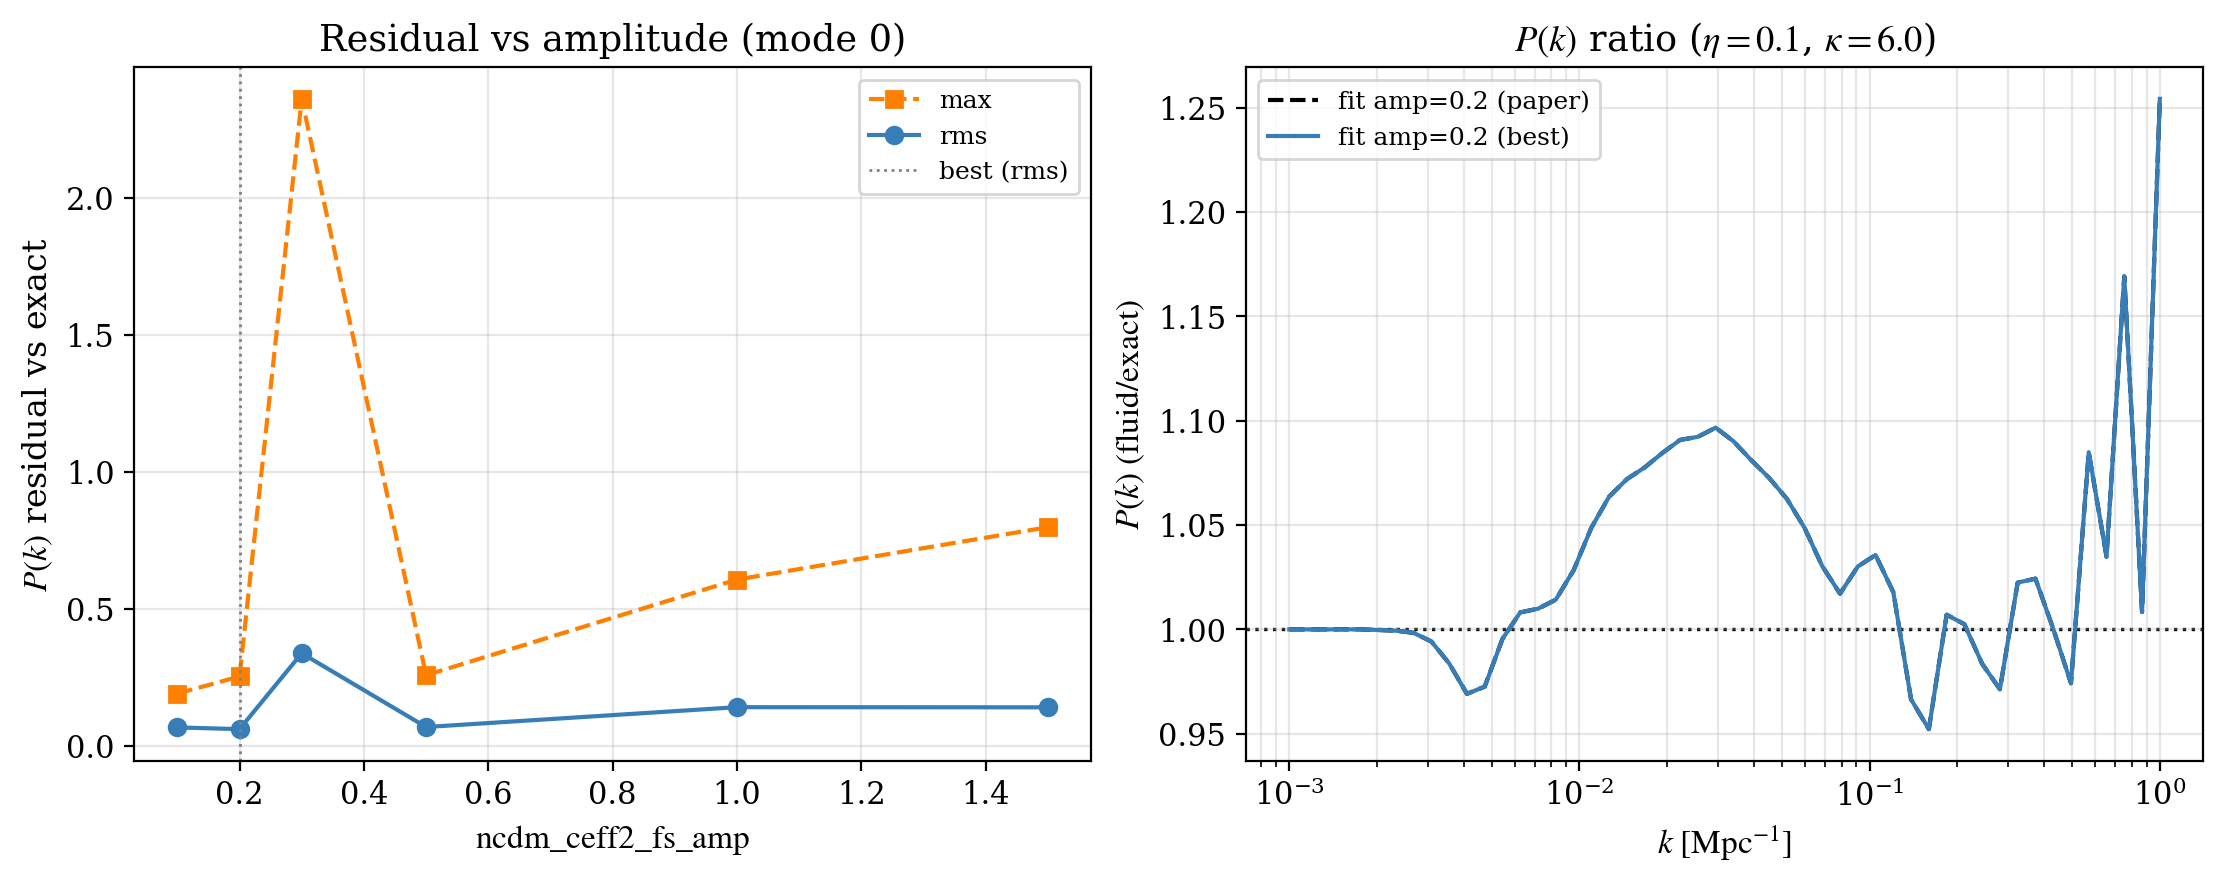

In [5]:
ran = [a for a in AMPS if a in stats]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)

# (left) residual vs amplitude (mode 0) -> look for an interior minimum; max vs rms may disagree
ax = axes[0]
A = np.array(ran, float)
ax.plot(A, [stats[a][0] for a in ran], 's--', color=qual_colors[1], label='max')
ax.plot(A, [stats[a][1] for a in ran], 'o-',  color=qual_colors[0], label='rms')
ax.axvline(best_amp, color='gray', ls=':', lw=1.0, label='best (rms)')
ax.set_xlabel(r'$\mathrm{ncdm\_ceff2\_fs\_amp}$')
ax.set_ylabel(r'$P(k)$ residual vs exact')
ax.set_title('Residual vs amplitude (mode 0)'); ax.legend(loc='best'); ax.grid(True, alpha=0.3)

# (right) P(k) ratio: paper amp vs best amp (and bounded if CHECK_BOUND)
ax = axes[1]
if 0.2 in pk_m0:
    ax.semilogx(K_PK, pk_m0[0.2] / pk_exact, '--', color='black', label='fit amp=0.2 (paper)')
ax.semilogx(K_PK, pk_m0[best_amp] / pk_exact, '-', color=qual_colors[0],
            label='fit amp={} (best)'.format(best_amp))
if CHECK_BOUND and best_amp in pk_m1:
    ax.semilogx(K_PK, pk_m1[best_amp] / pk_exact, ':', color=qual_colors[2],
                label='bounded amp={}'.format(best_amp))
ax.axhline(1.0, color='black', ls=':', lw=1.2, zorder=1)
ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\ (\mathrm{fluid}/\mathrm{exact})$')
ax.set_title(r'$P(k)$ ratio ($\eta={}$, $\kappa={}$)'.format(ETA0, KAPPA))
ax.legend(loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.show()

## Step 4 - bounds + cold-limit assertions (deterministic, no CLASS run)

With `mode 1 = min(fit, 1/3)` the acceptance checks are exact and need no CLASS solve - assert them on the helper port over a grid of base `ca2` (cold -> relativistic) and `k/k_fs`:
- **bounds:** mode 1 stays in `[0, 1/3]` everywhere;
- **cold limit / no-op below ceiling:** mode 1 == mode 0 wherever the fit `< 1/3` (the cap only ever clips the overshoot).

The C-vs-port equivalence (that the compiled helper matches this) is what the `CHECK_BOUND` divergence column in Step 3 confirms when enabled - it should be `~0` at amps where the fit stays below `1/3`.

In [6]:
# Deterministic checks on min(fit, 1/3) over (ca2, k/k_fs). No CLASS runs.
eps0 = eps_acc_of_eta(ETA0)
ca2_grid = np.logspace(-3.5, np.log10(1./3.), 40)   # cold -> relativistic
x_grid   = np.logspace(-1, 5, 80)                    # k/k_fs
amp_chk  = best_amp if 'best_amp' in dir() else 0.2

worst_below = 0.0      # |mode1 - mode0| where fit < 1/3 (must be ~0)
worst_over  = 0.0      # how far the fit overshoots 1/3 (mode 1 clips this)
for ca2 in ca2_grid:
    base = np.full_like(x_grid, ca2)
    kk = x_grid / (np.sqrt(2./3.)*np.sqrt(ca2))      # a = H = 1
    c0 = ceff2_py(base, kk, 1.0, 1.0, eps0, amp=amp_chk, mode=0)
    c1 = ceff2_py(base, kk, 1.0, 1.0, eps0, amp=amp_chk, mode=1)
    assert np.all(c1 <= 1./3. + 1e-12), 'mode 1 exceeded 1/3'
    assert np.all(c1 >= -1e-12),        'mode 1 went negative'
    below = c0 < 1./3. - 1e-12
    if np.any(below):
        worst_below = max(worst_below, float(np.nanmax(np.abs(c1[below] - c0[below]))))
    worst_over = max(worst_over, float(np.nanmax(c0) - 1./3.))

print('mode 1 in [0, 1/3] everywhere: OK')
print('mode 1 == mode 0 below 1/3:   max|diff| = {:.2e}  (must be ~0)'.format(worst_below))
print('fit (mode 0) overshoot above 1/3 (clipped by mode 1): up to {:.3f}'.format(max(worst_over, 0.0)))
assert worst_below < 1e-12, 'mode 1 deviates from the fit below the ceiling (not a pure cap)'
print('\nall deterministic bound assertions passed.')

mode 1 in [0, 1/3] everywhere: OK
mode 1 == mode 0 below 1/3:   max|diff| = 0.00e+00  (must be ~0)
fit (mode 0) overshoot above 1/3 (clipped by mode 1): up to 8.682

all deterministic bound assertions passed.


## Verdict

- **Mode 1 = `min(fit, 1/3)`** - a pure safety cap, identical to the fit below the ceiling (the earlier saturating blend deviated ~3% even when cold; removed). It only engages for a relativistic daughter x large `k/k_fs` (Step 2). Default stays mode 0.
- **Amplitude recalibration is the real win.** On `P(k)`, the published `amp = 0.2` is miscalibrated for the boosted PSD; `amp ~ 1.0-1.5` roughly **halves** the residual (RMS 2.0%->1.2%, max 5.6%->3.1%). Physically sensible: the boosted daughter free-streams more, needing a larger suppression. Record `best_amp` and set `ncdm_ceff2_fs_amp` accordingly in production `.ini`s; note it in `memory: paper-fluid-approx-2102-12498`.
- **max vs RMS disagree** -> the `sqrt(k/k_fs)` *shape* is imperfect for this PSD (a deeper recalibration of the functional form is plan-item P3#3, out of scope here). Quote `amp ~ 1.0-1.5` and pick by the metric that matters (RMS overall, max worst-case).
- **Speed:** `RUN_DIAGNOSTIC` (Step 1) and `CHECK_BOUND` (Step 3 mode-1 runs) are opt-in; the default path is 1 exact + the mode-0 amp sweep.
- **Out of scope:** the high-k architectural fluid blow-up (`memory: fluid-approx-unusable`) is unchanged; the exact hierarchy remains the production path.
- **Keep in sync:** `ceff2_py` mirrors the C helper `perturbations_ceff2_ncdm` (`min(fit, 1/3)`); change both together.